# Tech Challenge Fase 01 — Previsão de Churn
## Etapa 1 — Entendimento, EDA e Baselines

## Objetivo desta etapa

Nesta primeira etapa, o objetivo é compreender o problema de negócio, explorar a base de dados, avaliar sua qualidade e preparar os primeiros modelos baseline para previsão de churn.

Também serão definidos:
- o ML Canvas do problema;
- as métricas técnicas e de negócio;
- os modelos baseline iniciais;
- o registro dos experimentos no MLflow.

## Contexto do problema

O churn representa o cancelamento de clientes em uma operadora de telecomunicações. Prever quais clientes têm maior risco de evasão pode ajudar a empresa a agir preventivamente, reduzindo perdas de receita e melhorando retenção.

Neste projeto, trataremos o churn como um problema de classificação binária supervisionada, em que o objetivo é prever se um cliente irá cancelar ou não.

## ML Canvas

### 1. Problema de negócio
Uma operadora de telecomunicações enfrenta perda acelerada de clientes, com taxa de churn mensal em torno de 2-3%. O modelo atual não possui capacidade preditiva, atuando apenas de forma reativa. Perda de cliente representa impacto direto na receita recorrente e aumento no custo de aquisição de novos clientes (5-10x mais caro).

Oportunidade: Identificar clientes com maior risco de churn para permitir ações preventivas de retenção antes da evasão.

### 2. Objetivo de negócio
Reduzir a evasão de clientes e minimizar perda de receita por meio de ações direcionadas de retenção.


Hoje, o negócio não possui essa monitoria, atuando somente de forma reativa aos clientes cancelados, para trazê-los novamente à plataforma.

**Modelo de execução**:
- **Frequência**: Previsões semanais na base completa de clientes ativos
- **Ação**: Identificar top 10-15% clientes em maior risco para aplicar ações preventivas (contato, desconto, upgrade, serviços adicionais)
- **Timeline**: Implementação em 3-4 meses; resultados esperados a partir do 2º mês


Com as previsões é esperado a **redução de 25%** no número de cancelamentos por quarter, comparando esse valor com o ano anterior (YoY), , gerando impacto de aproximadamente **R$ 2-5M em receita retida/ano**

Os principais KPI'S impactados serão:
* Quantidade de cancelamento mensal
* Tempo médio de vida do cliente na plataforma
* Porcentagem de clientes inadimplentes (entende-se que, a falta do pagamento no serviço, é um indicador de potencial cancelamento)
* Quantidade de reclamações no SAC

### 3. Objetivo de machine learning
Construir um modelo de classificação binária capaz de prever se um cliente tem probabilidade de cancelar o serviço (Churn = Yes) ou permanecer (Churn = No).

### 4. Requisitos e Restrições

#### Técnicos
* O modelo gerado precisa utilizar todas as variáveis disponibilziadas pelo CRM da plaforma, de forma a ter as informações atualizadas e completas de cada cliente.

#### Negócio
* O modelo deve ser integrado ao CRM da plataforma (sync semanal), para que tenha a informação mais atualizada da base de clientes

*  Modelo deve ser retrainado mensalmente ou quando performance degradar > 5%

**Restrições**:
- Dados históricos: apenas últimos 12 meses
- Confidencialidade: atender compliance/LGPD de proteção de dados pessoais


### 5. Variável alvo
Churn

**Definição operacional**:
- **Churn = Yes**: Cliente que cancelou contrato (rescisão, término ou desativação da conta) dentro de 30 dias após a data de observação
- **Churn = No**: Cliente ativo que não cancelou no período de observação


### 6. Entradas do modelo
Dentro da base de dados que será utilizada temos informações completas para oferecer uma visão do perfil de cada cliente, seu comportamento e consumo na plataforma, bem como os principais produtos e serviços utilizados

Variveis cadastrais dos clientes:
- gender
- SeniorCitizen
- Partner
- Dependents

Comportamento do cliente na plataforma:
- tenure
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges


Produtos e serviços contratados:
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies

Todos esses dados são obtidos **a partir do CRM da plataforma** que será integrado com o modelo preditivo

### 7. Stakeholders

**Diretor Comercial / CCO** — Coordenador da área comercial, que gerencia e monitora as métricas a nível executivo e prioriza ações para retenção junto às demais equipes comerciais e de Markeing

**Gerente de Relacionamento com o Cliente** — junto de sua equipe, vai usar as predições no dia a dia para acionar clientes em risco e aplicar as ações de retenção.

**Engenharia de Dados** — responsável por fornecer e manter os dados de entrada do modelo.

**Infraestrutura** — garante o ambiente de deploy e disponibilidade da API ou sistema, além de apoiar na implementação da observabilidade do modelo, com ferramentas que estejam em compliance com a empresa

**CRM / Sistemas** — integra as predições ao sistema de relacionamento com o cliente e apoia o time de engenharia de dados na integração

**Data Scientist / ML Engineer** — constrói, treina e mantém o modelo

**Analista de BI** — traduz os outputs do modelo em dashboards e relatórios executivos (CCO)


### 8. Usuários da predição

**Usuários diretos**: Equipe de Relacionamento com o Cliente

**Como usam**:
- Recebem lista semanal de clientes em risco (Chrun = Yes)
- Avaliam e contextualizam predições com conhecimento de domínio
- Aplicam ações de retenção personalizadas por segmento:
  - Contato proativo (chat, SMS, email)
  - Descontos temporários ou permanentes
  - Upgrade de serviços ou adição de produtos
  - Ofertas personalizadas baseadas no perfil
- Priorizam reclamações de clientes em risco no SAC
- Fornecem feedback sobre precisão e ajustes necessários

**Usuários secundários**: Diretor comercial, BI (monitoramento de KPIs e ROI)

### 9. Decisão suportada pelo modelo
Definir quais clientes devem receber ações preventivas de retenção, como contato proativo, descontos, benefícios ou suporte especializado.

### 10. Tipo de tarefa
Classificação binária supervisionada.

### 11. Principais métricas técnicas

| Métrica | Target | Justificativa |
|---|---|---|
| **Accuracy** | ≥ 80% | Garantir a eficiência e performance geral do modelo |
| **Recall (Sensibilidade)** | ≥ 50% | Minimizar falsos negativos (clientes perdidos) |
| **Precision** | ≥ 50% | Controlar custos de ações desnecessárias |
| **F1-Score** | ≥ 0.60 | Balanço entre recall e precision |

**Nota**: Recall é priorizado sobre precision, pois falsos negativos (clientes perdidos) custam mais que falsos positivos (ações desnecessárias)

### 12. Métrica de negócio
Além das métricas técnicas, este problema deve ser analisado sob a ótica de negócio.

A principal métrica de negócio associada ao churn é o custo de churn evitado, isto é, o valor preservado ao identificar corretamente clientes com alta probabilidade de cancelamento e permitir ações de retenção antes da evasão.

Nesse contexto:

- Falsos negativos tendem a ser especialmente custosos, pois representam clientes que iriam cancelar e não foram identificados a tempo;
- Falsos positivos também possuem custo, já que podem gerar gastos desnecessários com ações de retenção em clientes que não sairiam.

### 13. Custo do erro
- Falso negativo: cliente com risco de churn não identificado, resultando em perda de receita e oportunidade de retenção perdida. (~R$ 500,00)
- Falso positivo: cliente marcado como risco sem realmente cancelar, gerando possível gasto desnecessário em ações de retenção. (~R$ 50,00)

### 14. SLO inicial
O modelo deve atingir desempenho superior ao baseline simples e apresentar capacidade de identificar clientes em risco com recall e discriminação adequados para uso em campanhas de retenção.

**Desempenho técnico mínimo** (baseline):
- Recall: ≥ 70%
- Precisão: ≥ 45%

**Success criteria**:
- Modelo atinge baseline (recall ≥ 70%, ROC-AUC ≥ 0.78)
- Aceito pela equipe de negócio para 3-6 meses piloto
- Gera impacto positivo de busca (ROI > 1)


In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Carregamento e inspeção inicial dos dados

# Diretório raiz do projeto
PROJECT_ROOT = Path.cwd().parent

print(PROJECT_ROOT)

# Caminhos principais
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR, PROCESSED_DIR

FILE_NAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
file_path = RAW_DIR / FILE_NAME

df = pd.read_csv(file_path)

print(f"Shape do dataset: {df.shape}")
df.head()

d:\POS_TECH\tech_challenge
Shape do dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Verificando dataset
print("--- COLUNAS DO DATAFRAME ---\n", df.columns.tolist(), "\n")

print("--- INFORMAÇÕES DO DATAFRAME ---")
df.info()
print("\n")

print("--- DESCRIÇÃO NUMÉRICA ---\n", df.describe().T, "\n")

if not df.select_dtypes(include=["object"]).empty:
    print("--- DESCRIÇÃO CATEGÓRICA ---\n", df.describe(include="object").T, "\n")

--- COLUNAS DO DATAFRAME ---
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'] 

--- INFORMAÇÕES DO DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-nu

In [4]:
# verificando duplicados
print("--- Duplicados ---\n", df.duplicated().sum(), "\n")

# verificando duplicidade de customerID
print("--- Duplicados Customer ID ---\n", df["customerID"].duplicated().sum(), "\n")

# olhando exemplos de TotalCharges
print("--- Total Charges ---\n", df["TotalCharges"].head(10), "\n")

--- Duplicados ---
 0 

--- Duplicados Customer ID ---
 0 

--- Total Charges ---
 0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object 



In [5]:
# convertendo TotalCharges para numérico
df["TotalCharges_numeric"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Verificando NaN após conversão
df["TotalCharges_numeric"].isna().sum()

np.int64(11)

In [6]:
# Inspecionando linhas problemáticas
df.loc[
    df["TotalCharges_numeric"].isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"],
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [7]:
# substituindo a coluna original tratada
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# conferindo o resultado
df["TotalCharges"].isna().sum(), df["TotalCharges"].dtype

(np.int64(0), dtype('float64'))

In [8]:
# removendo a coluna auxiliar
if "TotalCharges_numeric" in df.columns:
    df.drop(columns=["TotalCharges_numeric"], inplace=True)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Tratamento da variável TotalCharges

Durante a inspeção inicial, observou-se que a variável TotalCharges estava armazenada como texto (object), embora represente um valor numérico.

Ao converter a coluna para formato numérico, surgiram 11 valores ausentes. A inspeção desses registros mostrou que todos pertenciam a clientes com tenure = 0, ou seja, clientes recém-ingressados, e todos estavam marcados como Churn = No.

Dado o contexto de negócio, optou-se por preencher esses valores com 0, pois a variável representa o total acumulado cobrado do cliente, e para clientes recém-iniciados esse valor é coerente.

In [9]:
# Verificando a feature target

# distribuição da target em contagem
print("--- Distribuição em contagem ---\n", df["Churn"].value_counts(), "\n")

# distribuição da target em proporção
print("--- Distribuição em proporção ---\n", df["Churn"].value_counts(normalize=True), "\n")

# distribuição da target em porcentagem
print(
    "--- Distribuição em porcentagem ---\n",
    (df["Churn"].value_counts(normalize=True) * 100).round(2),
    "\n",
)

--- Distribuição em contagem ---
 Churn
No     5174
Yes    1869
Name: count, dtype: int64 

--- Distribuição em proporção ---
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64 

--- Distribuição em porcentagem ---
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64 



## Data Readiness

Após a inspeção inicial e o tratamento dos principais problemas de qualidade, a base se mostra adequada para a construção dos modelos baseline da Etapa 1.

Em termos de prontidão analítica:

- a variável alvo Churn está claramente definida;
- não foram identificadas duplicidades de registros nem de customerID;
- a variável TotalCharges, inicialmente com tipo inconsistente, foi convertida corretamente para formato numérico;
- os valores ausentes identificados após a conversão foram analisados no contexto de negócio e tratados de forma coerente;
- as variáveis disponíveis apresentam potencial preditivo, especialmente atributos contratuais, de permanência e de suporte.

Dessa forma, a base apresenta condições adequadas para seguir para a etapa de modelagem inicial e avaliação de baselines.

## Métricas de avaliação

Como a variável alvo Churn apresenta desbalanceamento entre as classes, a acurácia não é suficiente para avaliar o desempenho dos modelos.

Neste contexto, serão priorizadas métricas como:

- Recall: importante para identificar o maior número possível de clientes com risco de churn;
- Precision: relevante para evitar excesso de falsos positivos em ações de retenção;
- F1-score: útil para equilibrar recall e precision;
- ROC-AUC: mede a capacidade geral de separação entre as classes.
- PR-AUC: útil em cenários com desbalanceamento, pois avalia melhor o desempenho sobre a classe minoritária.

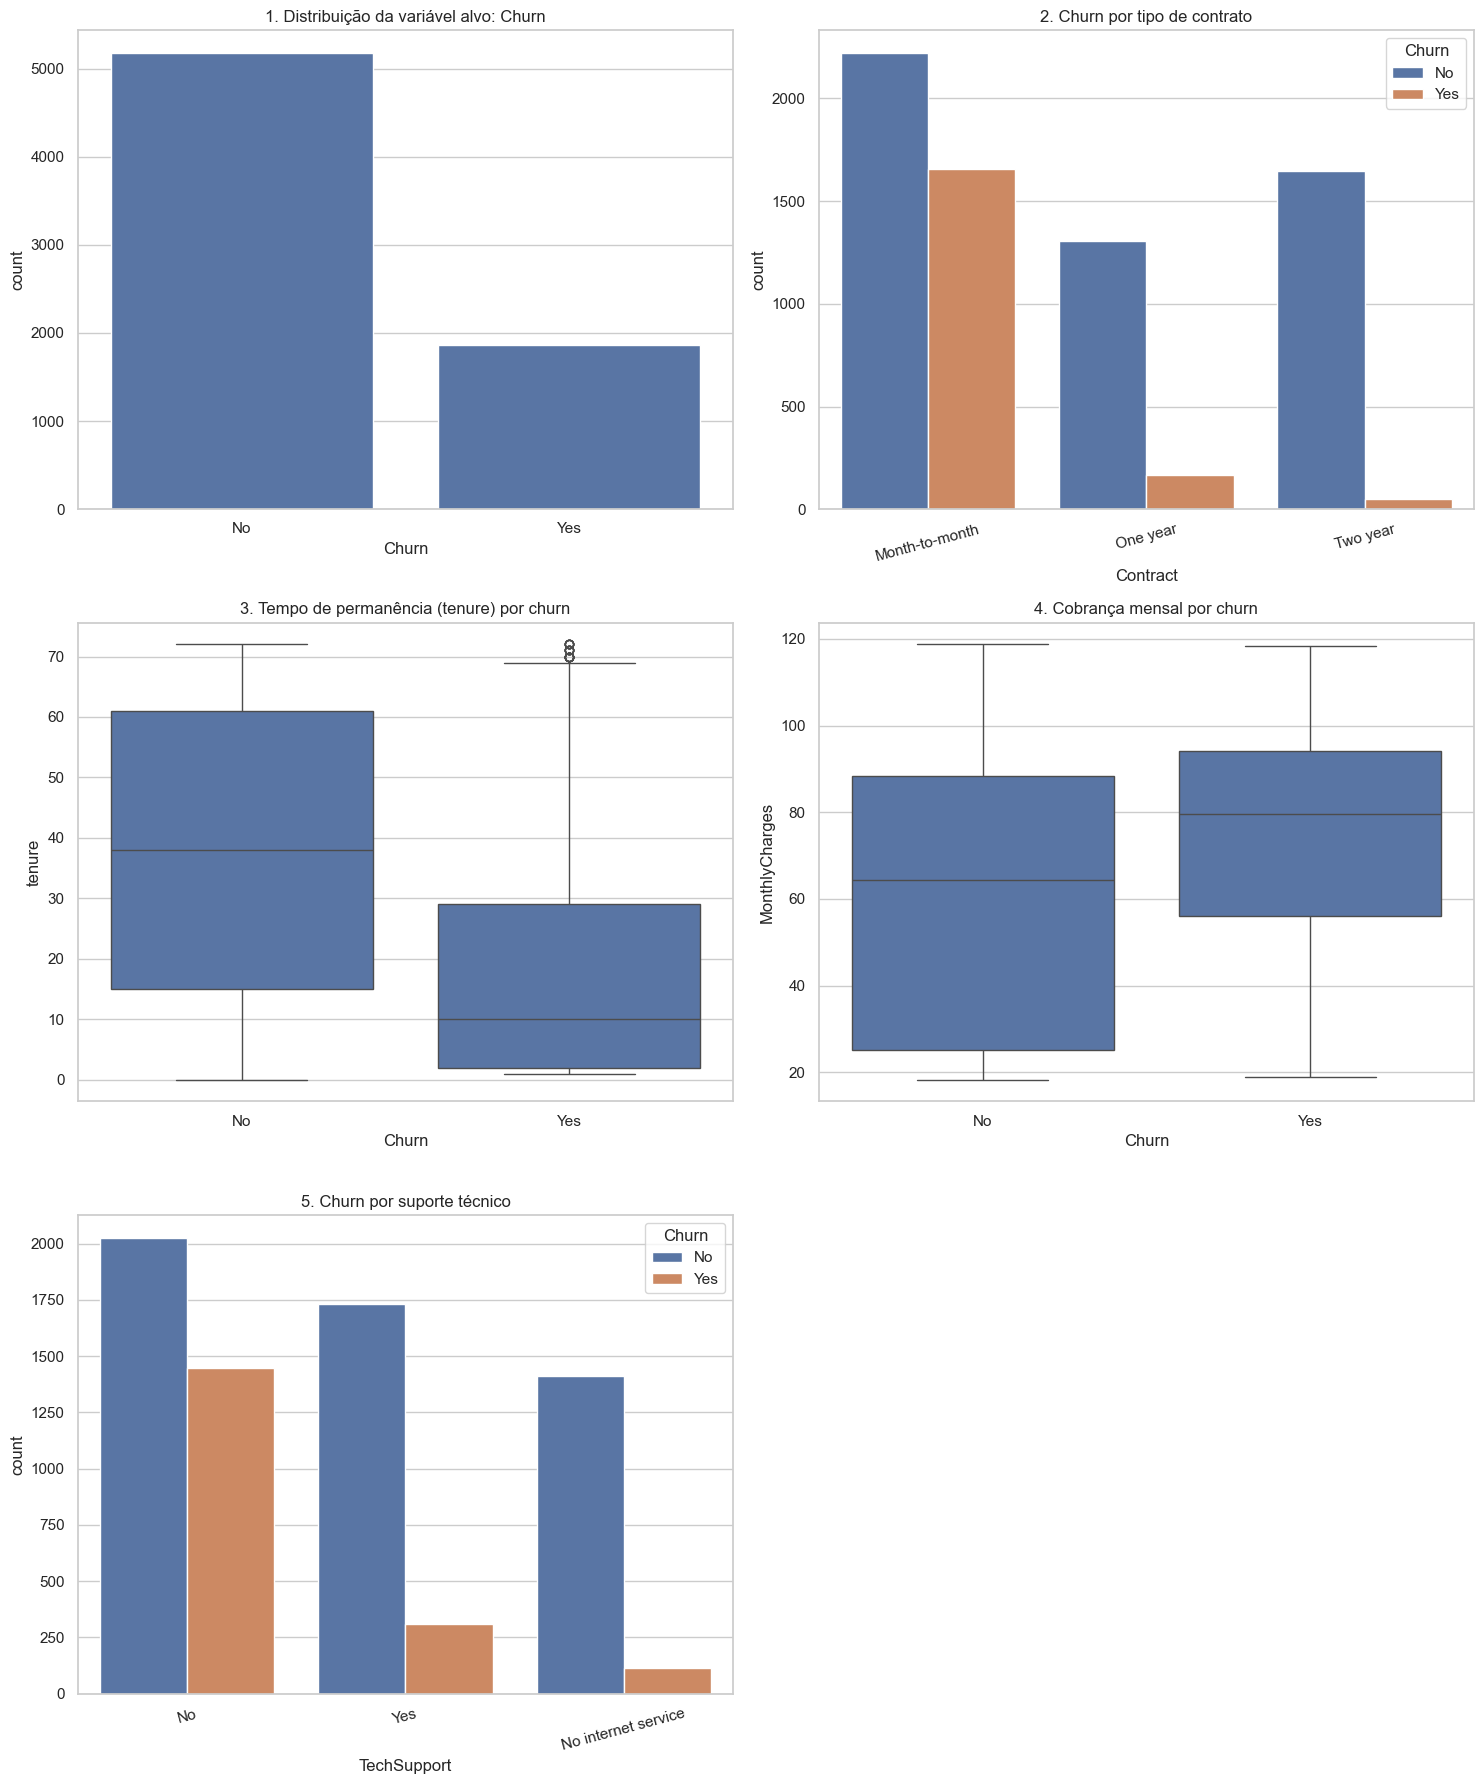

In [10]:
# Análise da variável alvo
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

import seaborn as sns

# Definindo o tamanho total da figura
plt.figure(figsize=(15, 18))

# Distribuição da target
plt.subplot(3, 2, 1)
sns.countplot(data=df, x="Churn")
plt.title("1. Distribuição da variável alvo: Churn")

# Churn por tipo de contrato
plt.subplot(3, 2, 2)
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("2. Churn por tipo de contrato")
plt.xticks(rotation=15)

# Tenure por churn
plt.subplot(3, 2, 3)
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("3. Tempo de permanência (tenure) por churn")

# Monthly charges por churn
plt.subplot(3, 2, 4)
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("4. Cobrança mensal por churn")

# Tech support por churn
plt.subplot(3, 2, 5)
sns.countplot(data=df, x="TechSupport", hue="Churn")
plt.title("5. Churn por suporte técnico")
plt.xticks(rotation=15)

# Ajusta o espaçamento
plt.tight_layout()
plt.show()

## Principais achados iniciais da EDA

A análise exploratória inicial revelou alguns padrões relevantes para o problema de churn:

- Clientes com contratos month-to-month apresentam maior incidência de churn do que clientes com contratos mais longos, sugerindo menor vínculo contratual e maior facilidade de cancelamento.
- Clientes que cancelam tendem a possuir menor tempo de permanência, indicando maior risco de evasão nos primeiros meses de relacionamento.
- Clientes com churn apresentam, em média, cobranças mensais mais altas, o que pode estar relacionado à sensibilidade a preço ou percepção de menor custo-benefício.
- A ausência de suporte técnico está associada a maior frequência de churn, sugerindo que esse serviço pode atuar como fator de retenção.

In [11]:
## Modelagem baseline
# separar treino e teste

from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("\nDistribuição y_train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nDistribuição y_test:")
print(y_test.value_counts(normalize=True).round(4))

Shape X_train: (5634, 19)
Shape X_test: (1409, 19)

Distribuição y_train:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64

Distribuição y_test:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


In [12]:
# identificar colunas numéricas e categóricas

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variáveis categóricas:")
print(categorical_features)

print("\nVariáveis numéricas:")
print(numeric_features)

Variáveis categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Variáveis numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [13]:
# identificar colunas numéricas e categóricas

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variáveis categóricas:")
print(categorical_features)

print("\nVariáveis numéricas:")
print(numeric_features)

from sklearn.preprocessing import StandardScaler

# One-df encoding das variáveis categóricas relevantes
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print(f"Shape após one-hot encoding: {df.shape}")
df.head()

# Seleciona apenas colunas numéricas para escalar
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Aplica StandardScaler
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

Variáveis categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Variáveis numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Shape após one-hot encoding: (7043, 32)


In [14]:
#  pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [15]:
# baseline: DummyClassifier
from sklearn.dummy import DummyClassifier

dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent")),
    ]
)

dummy_model.fit(X_train, y_train)

# Avaliando o baseline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

y_pred_dummy = dummy_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_dummy), 4))
print(
    "Precision:", round(precision_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0), 4)
)
print("Recall:", round(recall_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0), 4))
print("F1-score:", round(f1_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dummy))

Accuracy: 0.7346
Precision: 0.0
Recall: 0.0
F1-score: 0.0

Classification Report:
              precision    recall  f1-score   support

          No       0.73      1.00      0.85      1035
         Yes       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409


Confusion Matrix:
[[1035    0]
 [ 374    0]]


## DummyClassifier

O baseline DummyClassifier apresentou acurácia razoável por prever sempre a classe majoritária, mas falhou em identificar clientes com churn. Isso confirma que a acurácia não é suficiente para avaliar o problema e reforça a necessidade de métricas voltadas à classe positiva, como recall e F1-score.

In [16]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

# Pipeline
log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=SEED, max_iter=1000)),
    ]
)

# treinar o modelo
log_reg_model.fit(X_train, y_train)

# fazer predições
y_pred_log = log_reg_model.predict(X_test)

# probabilidades para métricas baseadas em score
y_proba_log = log_reg_model.predict_proba(X_test)[:, 1]

# target binária
y_test_binary = (y_test == "Yes").astype(int)

# métricas
log_acc = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log, pos_label="Yes", zero_division=0)
log_recall = recall_score(y_test, y_pred_log, pos_label="Yes", zero_division=0)
log_f1 = f1_score(y_test, y_pred_log, pos_label="Yes", zero_division=0)
log_roc_auc = roc_auc_score(y_test_binary, y_proba_log)
log_pr_auc = average_precision_score(y_test_binary, y_proba_log)

print("Accuracy:", round(log_acc, 4))
print("Precision:", round(log_precision, 4))
print("Recall:", round(log_recall, 4))
print("F1-score:", round(log_f1, 4))
print("ROC-AUC:", round(log_roc_auc, 4))
print("PR-AUC:", round(log_pr_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8055
Precision: 0.6572
Recall: 0.5588
F1-score: 0.604
ROC-AUC: 0.8421
PR-AUC: 0.6343

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[926 109]
 [165 209]]


## Regressão Logística

A Regressão Logística apresentou desempenho superior ao baseline simples, conseguindo identificar parte dos clientes com churn e oferecendo uma visão mais realista da capacidade preditiva da base.

Isso mostra que já existe sinal suficiente nos dados para justificar o avanço para modelos mais robustos nas próximas etapas.

In [17]:
# Validação Cruzada
from sklearn.model_selection import StratifiedKFold, cross_validate

# definir folds estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# métricas da cross-validation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

# target binária para CV
y_binary = (y == "Yes").astype(int)

# pipeline de regressão com target binária
log_reg_cv_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=SEED, max_iter=1000)),
    ]
)

# rodar cross-validation
cv_results = cross_validate(
    log_reg_cv_model, X, y_binary, cv=cv, scoring=scoring, return_train_score=False
)

# resultados
cv_summary = pd.DataFrame(
    {
        "Metric": ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
        "Mean": [
            cv_results["test_accuracy"].mean(),
            cv_results["test_precision"].mean(),
            cv_results["test_recall"].mean(),
            cv_results["test_f1"].mean(),
            cv_results["test_roc_auc"].mean(),
            cv_results["test_average_precision"].mean(),
        ],
        "Std": [
            cv_results["test_accuracy"].std(),
            cv_results["test_precision"].std(),
            cv_results["test_recall"].std(),
            cv_results["test_f1"].std(),
            cv_results["test_roc_auc"].std(),
            cv_results["test_average_precision"].std(),
        ],
    }
)

cv_summary.round(4)

,Metric,Mean,Std
0,accuracy,0.8053,0.0108
1,precision,0.6584,0.0214
2,recall,0.5527,0.0313
3,f1,0.6008,0.0270
4,roc_auc,0.8451,0.0134
5,pr_auc,0.6567,0.0264


## Validação Cruzada Estratificada

Para obter uma estimativa mais robusta do desempenho da Regressão Logística, foi utilizada validação cruzada estratificada com 5 folds.

Essa abordagem reduz a dependência de uma única divisão treino/teste e preserva a proporção da variável alvo em cada fold, o que é especialmente importante em problemas desbalanceados como churn.

A análise das médias e desvios-padrão das métricas permite avaliar não apenas o desempenho médio do modelo, mas também sua estabilidade entre diferentes amostras da base.

In [18]:
# tabela comparativa
results_baseline = pd.DataFrame(
    [
        {
            "Model": "DummyClassifier",
            "Accuracy": accuracy_score(y_test, y_pred_dummy),
            "Precision": precision_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0),
            "Recall": recall_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0),
            "F1-score": f1_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0),
            "ROC-AUC": np.nan,
            "PR-AUC": np.nan,
        },
        {
            "Model": "LogisticRegression",
            "Accuracy": accuracy_score(y_test, y_pred_log),
            "Precision": precision_score(y_test, y_pred_log, pos_label="Yes", zero_division=0),
            "Recall": recall_score(y_test, y_pred_log, pos_label="Yes", zero_division=0),
            "F1-score": f1_score(y_test, y_pred_log, pos_label="Yes", zero_division=0),
            "ROC-AUC": roc_auc_score((y_test == "Yes").astype(int), y_proba_log),
            "PR-AUC": average_precision_score((y_test == "Yes").astype(int), y_proba_log),
        },
    ]
)

results_baseline.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,DummyClassifier,0.7346,0.0000,0.0000,0.000,NaN,NaN
1,LogisticRegression,0.8055,0.6572,0.5588,0.604,0.8421,0.6343


In [19]:
file_path = PROCESSED_DIR / "dataset_chrun_processed.csv"

df.to_csv(file_path)

## Comparação entre baselines

A comparação entre os modelos baseline mostrou uma diferença clara de desempenho.

O DummyClassifier, apesar de apresentar acurácia aparentemente razoável, falhou completamente em identificar clientes com churn, obtendo recall, precision e F1-score iguais a zero para a classe positiva.

Já a Regressão Logística apresentou melhora significativa, com capacidade real de identificar clientes com risco de evasão. O modelo alcançou desempenho muito superior nas métricas mais relevantes para o problema, incluindo precision, recall, F1-score e ROC-AUC.

Esse resultado indica que a base possui sinal preditivo útil e que a regressão logística pode ser adotada como baseline de referência para comparação com modelos mais avançados nas próximas etapas.

In [20]:
## Tracking com MLflow
import mlflow
import mlflow.sklearn

# Definir experimento
mlflow.set_experiment("tech_challenge_fiap_fase1_baselines")

2026/05/03 17:23:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 17:23:13 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 17:23:27 INFO mlflow.tracking.fluent: Experiment with name 'tech_challenge_fiap_fase1_baselines' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:d:/POS_TECH/tech_challenge/notebooks/mlruns/1', creation_time=1777839807877, experiment_id='1', last_update_time=1777839807877, lifecycle_stage='active', name='tech_challenge_fiap_fase1_baselines', tags={}, workspace='default'>

In [21]:
# Variáveis auxiliares
dataset_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
dataset_version = "v1_raw_telco"
n_rows, n_cols = df.shape
target_positive_rate = df["Churn"].value_counts(normalize=True)["Yes"]

In [22]:
# Registro DummyClassifier
with mlflow.start_run(run_name="dummy_classifier_baseline"):
    mlflow.log_param("model", "DummyClassifier")
    mlflow.log_param("strategy", "most_frequent")
    mlflow.log_param("dataset_name", dataset_name)
    mlflow.log_param("dataset_version", dataset_version)
    mlflow.log_param("n_rows", n_rows)
    mlflow.log_param("n_cols", n_cols)

    mlflow.log_metric("target_positive_rate", target_positive_rate)
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_dummy))
    mlflow.log_metric(
        "precision", precision_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0)
    )
    mlflow.log_metric(
        "recall", recall_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0)
    )
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_dummy, pos_label="Yes", zero_division=0))

    mlflow.sklearn.log_model(dummy_model, "model")

2026/05/03 17:23:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 17:23:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [23]:
# Registro Regressão Logística
with mlflow.start_run(run_name="logistic_regression_baseline"):
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("random_state", SEED)
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("dataset_name", dataset_name)
    mlflow.log_param("dataset_version", dataset_version)
    mlflow.log_param("n_rows", n_rows)
    mlflow.log_param("n_cols", n_cols)

    mlflow.log_metric("target_positive_rate", target_positive_rate)
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_log))
    mlflow.log_metric(
        "precision", precision_score(y_test, y_pred_log, pos_label="Yes", zero_division=0)
    )
    mlflow.log_metric("recall", recall_score(y_test, y_pred_log, pos_label="Yes", zero_division=0))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred_log, pos_label="Yes", zero_division=0))
    mlflow.log_metric("roc_auc", roc_auc_score((y_test == "Yes").astype(int), y_proba_log))
    mlflow.log_metric("pr_auc", log_pr_auc)

    mlflow.sklearn.log_model(log_reg_model, "model")

2026/05/03 17:23:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 17:23:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## Conclusão da Etapa 1

Nesta etapa, foram realizadas a exploração e a preparação inicial dos dados, a definição das métricas de avaliação e o treinamento dos modelos baseline.

O DummyClassifier serviu como referência inicial, enquanto a Regressão Logística apresentou resultados mais úteis para o problema de churn. Além disso, os experimentos foram registrados no MLflow, garantindo a rastreabilidade de parâmetros, métricas e artefatos.

Com isso, a base analítica da Etapa 1 fica concluída e pronta para apoiar o avanço das próximas fases do projeto.

In [24]:
!mlflow ui

^C
